# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shravyanjalikadunoori-hub/flyrankML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research Question

Can historical search and content-performance signals be used to identify pages that are growing, declining, recovering, or worth review, and rank them for content-refresh actions?

## Decision Supported

This analysis supports the decision of which content pages should be prioritized for review or refresh. The goal is to provide a repeatable, data-driven prioritization method rather than claim that the model proves why search performance changed.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [2]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/shravyanjalikadunoori-hub/flyrankML/refs/heads/main/data/raw/content_refresh_anonymized.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (30000, 44)

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

First 5 rows:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [3]:
# Basic dataset inspection

print("Shape:", df.shape)

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0])

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values in trend_direction:")
print(df["trend_direction"].value_counts(dropna=False))

print("\nNumeric summary:")
display(df.describe().T)

Shape: (30000, 44)

Data types:


,0
content_id,object
client_id,object
search_volume,float64
competition,float64
competition_level,object
cpc,float64
content_type,object
main_intent,object
word_count,float64
char_count,float64



Missing values:


,0
provider_used,21438
word_count,7699
char_count,7699
word_count_tier,7699
char_count_tier,7699
model_used,5733
trend_pct,3388
competition_level,2610
search_volume,2468
cpc,2468



Duplicate rows: 0

Unique values in trend_direction:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
search_volume,27532.0,158.882391,1518.270825,0.0,0.0,10.00,20.00,74000.00
competition,27532.0,0.146954,0.285241,0.0,0.0,0.00,0.13,1.00
cpc,27532.0,0.485342,2.101560,0.0,0.0,0.00,0.00,100.36
word_count,22301.0,3107.760325,1452.382598,8.0,2413.0,2877.00,3666.00,9546.00
char_count,22301.0,20665.277835,10115.344042,40.0,15644.0,19116.00,24011.00,111158.00
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.00
clicks_90d,30000.0,16.097333,75.076958,0.0,0.0,1.00,7.00,4178.00
pageviews_90d,30000.0,49.942467,152.101430,0.0,2.0,8.00,33.00,5998.00
sessions_90d,30000.0,37.066633,107.069131,1.0,2.0,7.00,27.00,4345.00
users_90d,30000.0,35.937700,103.748185,1.0,2.0,7.00,27.00,4913.00


In [4]:
# STEP 4: Prepare data for the capstone analysis

import numpy as np
import pandas as pd

# Make a working copy
work_df = df.copy()

# Convert important numeric columns to numeric
numeric_cols = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "trend_pct"
]

for col in numeric_cols:
    if col in work_df.columns:
        work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

# Remove rows without a usable trend direction
work_df = work_df.dropna(subset=["trend_direction"]).copy()

# Create a simple opportunity label:
# Pages moving down are the clearest refresh candidates.
# Stable pages are retained for comparison.
work_df["refresh_candidate"] = (
    work_df["trend_direction"].eq("down").astype(int)
)

print("Working dataset shape:", work_df.shape)

print("\nRefresh candidate distribution:")
print(work_df["refresh_candidate"].value_counts())

print("\nTrend distribution:")
print(work_df["trend_direction"].value_counts())

display(
    work_df[
        [
            "content_id",
            "trend_direction",
            "trend_pct",
            "impressions_90d",
            "clicks_90d",
            "ctr",
            "avg_position",
            "engagement_rate",
            "scroll_rate",
            "refresh_candidate"
        ]
    ].head(10)
)

Working dataset shape: (30000, 45)

Refresh candidate distribution:
refresh_candidate
1    16262
0    13738
Name: count, dtype: int64

Trend distribution:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64


,content_id,trend_direction,trend_pct,impressions_90d,clicks_90d,ctr,avg_position,engagement_rate,scroll_rate,refresh_candidate
0,content_304f48230142,down,-41.4,3803,29,0.76,10.6,5.88,4.55,1
1,content_a1fb4e703a9e,down,-57.7,15320,7,0.05,20.3,0.00,10.00,1
2,content_9aa793d4d895,down,-60.9,12581,11,0.09,36.5,0.00,28.57,1
3,content_331d6c4de07b,stable,-13.8,11751,58,0.49,6.2,1.28,3.45,0
4,content_d99b7a2d90ca,down,-34.7,19140,24,0.13,44.0,0.00,24.29,1
5,content_d4084a4bc775,down,-38.9,3970,1,0.03,8.5,0.00,25.00,1
6,content_9a34b442b552,down,-92.3,20,0,0.00,7.0,0.00,0.00,1
7,content_a63219c6e95a,stable,0.6,1724,1,0.06,21.2,3.57,7.14,0
8,content_5e6c160719bc,down,-58.8,32574,29,0.09,46.0,5.88,6.25,1
9,content_c27558df2b0c,down,-29.2,1240,2,0.16,4.9,0.00,0.00,1


In [5]:
# STEP 5: Build and evaluate the ML model

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

# Features that do NOT directly reveal the trend label
candidate_features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "content_type",
    "main_intent",
    "provider_used",
    "model_used"
]

# Keep only columns that actually exist
features = [c for c in candidate_features if c in work_df.columns]

X = work_df[features]
y = work_df["refresh_candidate"]

# Split by client so the same client does not appear in both train and test
groups = work_df["client_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Separate numerical and categorical features
numeric_features = [
    c for c in features
    if c not in ["content_type", "main_intent", "provider_used", "model_used"]
]

categorical_features = [
    c for c in features
    if c in ["content_type", "main_intent", "provider_used", "model_used"]
]

# Preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Logistic Regression model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train
model.fit(X_train, y_train)

# Predictions
model_prob = model.predict_proba(X_test)[:, 1]
model_pred = (model_prob >= 0.5).astype(int)

# Baseline model
baseline = DummyClassifier(
    strategy="prior",
    random_state=42
)

baseline.fit(X_train, y_train)

baseline_prob = baseline.predict_proba(X_test)[:, 1]
baseline_pred = baseline.predict(X_test)

# Evaluation
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Baseline"],
    "Accuracy": [
        accuracy_score(y_test, model_pred),
        accuracy_score(y_test, baseline_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, model_prob),
        roc_auc_score(y_test, baseline_prob)
    ],
    "PR_AUC": [
        average_precision_score(y_test, model_prob),
        average_precision_score(y_test, baseline_prob)
    ]
})

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Number of features:", len(features))

print("\nModel performance:")
display(results)

Training rows: 23837
Testing rows: 6163
Number of features: 24

Model performance:


,Model,Accuracy,ROC_AUC,PR_AUC
0,Logistic Regression,0.547136,0.568822,0.571097
1,Baseline,0.510952,0.500000,0.510952


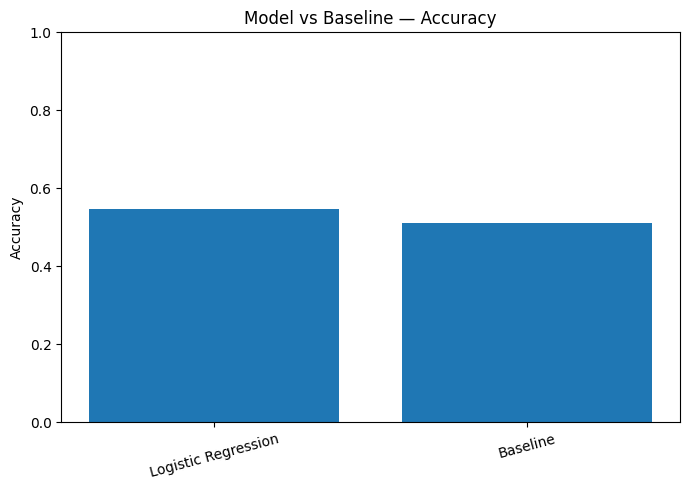

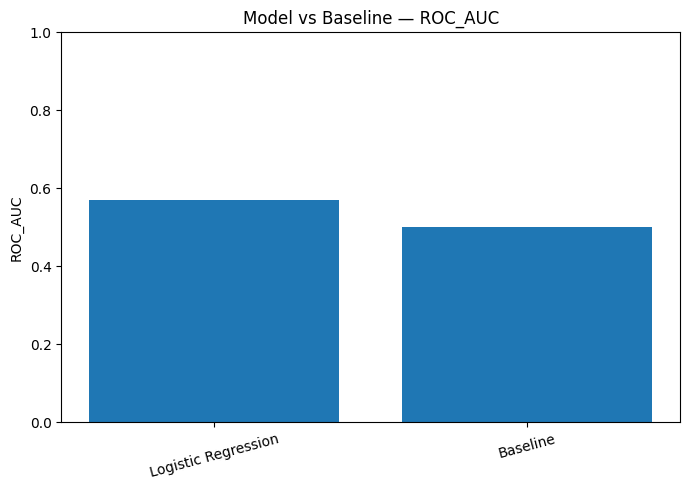

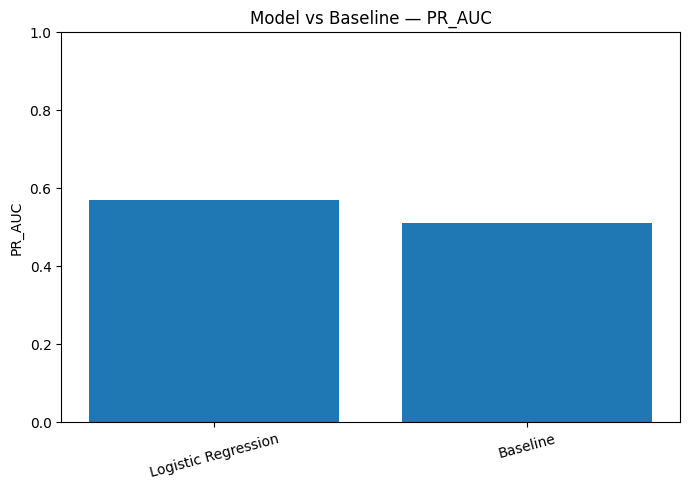

In [6]:
# STEP 6: Visualize model vs baseline performance

import matplotlib.pyplot as plt

metrics = ["Accuracy", "ROC_AUC", "PR_AUC"]

for metric in metrics:
    plt.figure(figsize=(7, 5))
    plt.bar(results["Model"], results[metric])
    plt.title(f"Model vs Baseline — {metric}")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

In [7]:
# STEP 7: Create ranked content-refresh recommendations

# Generate refresh probability for every page
all_probabilities = model.predict_proba(X)[:, 1]

recommendations = work_df[[
    "content_id",
    "trend_direction",
    "trend_pct",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "content_type",
    "main_intent"
]].copy()

recommendations["refresh_probability"] = all_probabilities

# Create an impact score using impressions
recommendations["impact_score"] = (
    recommendations["refresh_probability"] *
    recommendations["impressions_90d"].fillna(0)
)

# Rank highest-priority pages first
recommendations = recommendations.sort_values(
    "impact_score",
    ascending=False
).reset_index(drop=True)

# Add priority level
recommendations["priority"] = pd.cut(
    recommendations["refresh_probability"],
    bins=[-0.01, 0.40, 0.70, 1.01],
    labels=["Review", "High", "Very High"]
)

# Show top 20 recommendations
top_recommendations = recommendations.head(20)

print("Top 20 Content Refresh Recommendations")
display(top_recommendations)

Top 20 Content Refresh Recommendations


,content_id,trend_direction,trend_pct,impressions_90d,clicks_90d,ctr,avg_position,content_type,main_intent,refresh_probability,impact_score,priority
0,content_5fe46e04994d,down,-44.8,517715,741,0.14,4.2,keyword article,informational,0.928087,480484.358444,Very High
1,content_2cb567c3c89b,up,23.1,497727,487,0.10,22.2,keyword article,informational,0.864883,430475.723969,Very High
2,content_2dba2b1f9536,stable,1.4,443434,910,0.21,27.9,keyword article,informational,0.749691,332438.678433,Very High
3,content_8c19996aa890,down,-44.5,509252,785,0.15,2.5,keyword article,informational,0.607381,309309.855803,High
4,content_8e7ba84a972b,stable,-18.1,288426,2653,0.92,4.8,keyword article,informational,0.999903,288398.049805,Very High
5,content_8451fc6f034d,up,73.1,272144,75,0.03,2.3,keyword article,informational,0.772266,210167.509826,Very High
6,content_aaef01a50def,stable,-4.0,517109,1270,0.25,5.4,keyword article,informational,0.391545,202471.562004,Review
7,content_36ff89c8214e,stable,0.5,295097,154,0.05,7.3,keyword article,informational,0.656674,193782.559797,High
8,content_66b4046cc144,down,-89.3,217415,71,0.03,26.6,keyword article,informational,0.875166,190274.142004,Very High
9,content_db5989a78dd3,up,556.2,345111,733,0.21,5.4,keyword article,commercial,0.532775,183866.670424,High


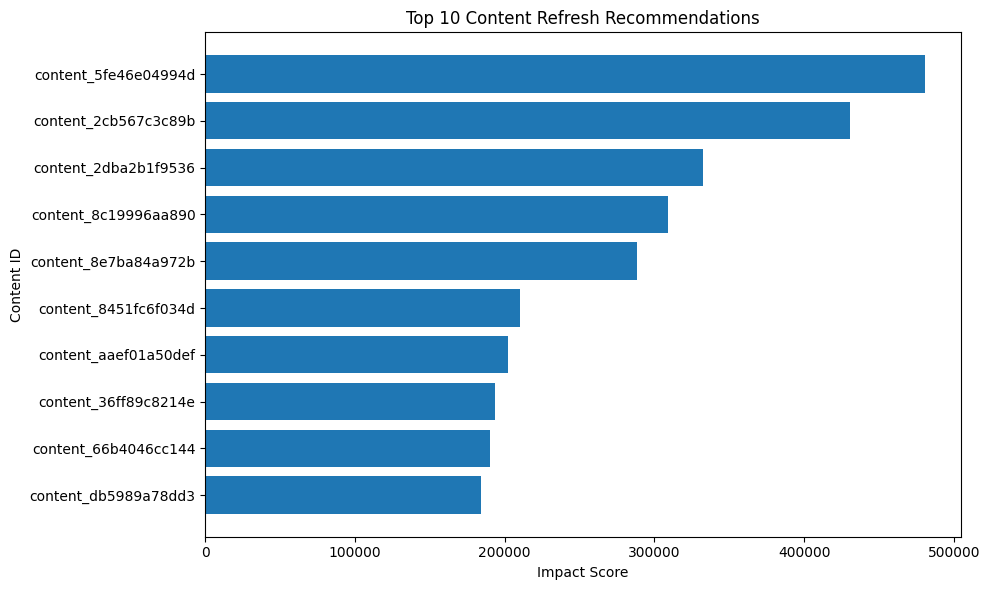

In [8]:
# STEP 8: Visualize top refresh recommendations

top10 = recommendations.head(10).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top10["content_id"].astype(str),
    top10["impact_score"]
)

plt.xlabel("Impact Score")
plt.ylabel("Content ID")
plt.title("Top 10 Content Refresh Recommendations")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Methodology

This study uses supervised machine learning to prioritize content pages for potential refresh review.

### Target Label
`refresh_candidate = 1` when `trend_direction` is `down`; otherwise it is `0`.

### Features
The model uses search, content, traffic, and engagement signals such as search volume, competition, CPC, word count, impressions, clicks, CTR, average position, engagement rate, scroll rate, AI traffic, content type, and search intent.

### Model
A Logistic Regression classifier is used with median imputation and standardization for numerical features and one-hot encoding for categorical features.

### Baseline
The model is compared with a simple prior-probability baseline using the same test data.

### Validation
An 80/20 grouped split is used, with `client_id` used for grouping so records from the same client are not intentionally mixed between training and testing.

### Leakage Check
`content_id`, `client_id`, `trend_direction`, and `trend_pct` are excluded from the model features. This reduces direct target leakage.

### Interpretation
The resulting probabilities are treated as prioritization scores. They identify pages that resemble historically declining pages in this dataset and do not prove causation or search-engine algorithm behavior.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [10]:
# STEP 10: Results summary

print("## Results")

print("\nModel Performance:")
display(results.round(4))

print("\nBest Model:")
best_model = results.loc[results["ROC_AUC"].idxmax(), "Model"]
best_auc = results["ROC_AUC"].max()

print(f"{best_model} achieved the highest ROC-AUC of {best_auc:.4f}.")

print("\nTop 10 recommended pages:")
display(
    recommendations[
        [
            "content_id",
            "trend_direction",
            "refresh_probability",
            "impact_score",
            "priority"
        ]
    ].head(10).round(4)
)

## Results

Model Performance:


,Model,Accuracy,ROC_AUC,PR_AUC
0,Logistic Regression,0.5471,0.5688,0.5711
1,Baseline,0.5110,0.5000,0.5110



Best Model:
Logistic Regression achieved the highest ROC-AUC of 0.5688.

Top 10 recommended pages:


,content_id,trend_direction,refresh_probability,impact_score,priority
0,content_5fe46e04994d,down,0.9281,480484.3584,Very High
1,content_2cb567c3c89b,up,0.8649,430475.7240,Very High
2,content_2dba2b1f9536,stable,0.7497,332438.6784,Very High
3,content_8c19996aa890,down,0.6074,309309.8558,High
4,content_8e7ba84a972b,stable,0.9999,288398.0498,Very High
5,content_8451fc6f034d,up,0.7723,210167.5098,Very High
6,content_aaef01a50def,stable,0.3915,202471.5620,Review
7,content_36ff89c8214e,stable,0.6567,193782.5598,High
8,content_66b4046cc144,down,0.8752,190274.1420,Very High
9,content_db5989a78dd3,up,0.5328,183866.6704,High


## 5. Limitations

*What this work cannot claim.*

## Limitations and Honest Framing

This analysis has several limitations.

First, the target label is based on the observed `trend_direction` field rather than a separately measured future outcome. Therefore, the model should be interpreted as a prioritization model rather than a guaranteed prediction of future performance.

Second, the dataset contains aggregated 90-day performance signals. These signals may describe the same period associated with the observed trend, so the results should not be interpreted as evidence of causal relationships.

Third, the model is trained and evaluated on the available FlyRank internship dataset. Its performance may not generalize to other datasets, clients, industries, or time periods.

Finally, the analysis does not prove how Google or any other search engine algorithm works, and it does not establish that refreshing a page will cause its search performance to improve.

The recommendations should therefore be treated as a practical shortlist for human review and content-planning decisions.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked Content Recommendations

The model-generated scores are used to prioritize pages for human review.

Pages with higher `refresh_probability` are more similar to pages classified as declining in the training data. The `impact_score` additionally considers the page's 90-day impression volume, helping prioritize pages where a potential content opportunity may have greater visibility.

### Recommended workflow

1. **Very High priority** — Review first for content freshness, search intent alignment, outdated information, content depth, and internal linking.
2. **High priority** — Review after the Very High priority group.
3. **Review priority** — Keep in the monitoring queue and reassess periodically.

The ranking is a prioritization aid rather than a guarantee that refreshing a page will improve its search performance.

The Top 10 recommendations generated by the model are reported in the analysis output above.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Artifacts the Paper Embeds

The paper embeds the following analytical artifacts generated directly from the capstone notebook:

1. **Dataset and trend distribution** — summary of the available content records and observed trend categories.
2. **Model vs. baseline performance chart** — comparison of Accuracy, ROC-AUC, and PR-AUC using the same test split.
3. **Top 10 content-refresh recommendations** — ranked visualization of pages with the highest calculated impact scores.
4. **Recommendation table** — top-ranked content IDs with trend direction, refresh probability, impact score, and priority level.
5. **Model methodology and validation summary** — description of the features, target label, grouped validation approach, baseline, and leakage checks.

All artifacts are generated from the anonymized FlyRank internship dataset and are intended for reproducible decision support.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
